### **Parte 5: Proyección III**

Cargamos las librerías necesarias, incluyendo las herramientas de clasificación de Scikit-Learn (RandomForestClassifier), y traemos nuestro dataset final estructurado, eliminando cualquier valor infinito o nulo residual para evitar errores en el algoritmo.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Herramientas de Clasificación
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, classification_report 

# Cargar dataset
df = pd.read_csv('../data/processed/movies_listo_para_modelo.csv')
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['roi', 'budget'])

print(f" Datos cargados: {df.shape[0]} películas.")

 Datos cargados: 3229 películas.


Transformamos el ROI numérico en una variable binaria (es_rentable) para que el modelo clasifique entre "Éxito" (1) o "Fracaso" (0). Seleccionamos estrictamente variables pre-estreno (presupuesto, géneros, estudios y experiencia del director) para evitar la fuga de datos, y dividimos el dataset reservando un 20% para poner a prueba el modelo.

In [37]:
# Celda 2: Definición de Variables

df['es_rentable'] = (df['roi'] > 0).astype(int)
y = df['es_rentable']

# VARIABLES PRE-ESTRENO
features = ['budget', 'es_drama', 'es_comedia', 'es_thriller', 
            'es_warner', 'es_universal', 'es_paramount', 'experiencia_director']
X = df[features]

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Entrenamiento: {X_train.shape[0]} |  Prueba: {X_test.shape[0]}")

Entrenamiento: 2583 |  Prueba: 646


Construimos un flujo automatizado (Pipeline).

 Primero, utilizamos StandardScaler para que todas nuestras variables numéricas queden en la misma escala (evitando que el presupuesto eclipse a las demás solo por tener muchos ceros). Inmediatamente después, entrenamos el algoritmo de Bosque Aleatorio (RandomForestClassifier) con los datos de entrenamiento.

In [38]:
# Celda 3: Pipeline Simplificado y Entrenamiento

# Como ahora todas las variables son numéricas, solo necesitamos el StandardScaler
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features)
    ])

modelo_pipeline_clf = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('algoritmo', RandomForestClassifier(n_estimators=100, random_state=42))
])

modelo_pipeline_clf.fit(X_train, y_train)
print("Modelo de Clasificación ético (pre-estreno) entrenado.")

Modelo de Clasificación ético (pre-estreno) entrenado.


Evaluamos el rendimiento del modelo utilizando los datos de prueba (X_test). Analizamos la métrica de Exactitud (Accuracy) para determinar el porcentaje de veces que el modelo adivinó correctamente el futuro financiero de las películas, acompañado de un reporte estadístico detallado.

In [ ]:
y_pred_clf = modelo_pipeline_clf.predict(X_test)

# Calcular Exactitud (Accuracy)
exactitud = accuracy_score(y_test, y_pred_clf)

print("---  RESULTADOS DE CLASIFICACIÓN ---")
print(f"Exactitud del Modelo (Accuracy): {exactitud * 100:.2f}%")

---  RESULTADOS DE CLASIFICACIÓN ---
Exactitud del Modelo (Accuracy): 69.97%

Reporte Detallado:
              precision    recall  f1-score   support

           0       0.30      0.18      0.22       157
           1       0.77      0.87      0.81       489

    accuracy                           0.70       646
   macro avg       0.53      0.52      0.52       646
weighted avg       0.65      0.70      0.67       646



Extraemos el "peso" que el modelo de Random Forest le asignó a cada característica al momento de tomar sus decisiones. Generamos un gráfico de barras que revela visualmente qué factores son los que realmente definen el éxito financiero en la industria del cine, dejando fuera variables engañosas como el mes de estreno o la popularidad post-lanzamiento.

C:\Users\aleee\AppData\Local\Temp\ipykernel_24544\1827875337.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia_clf, palette='viridis')


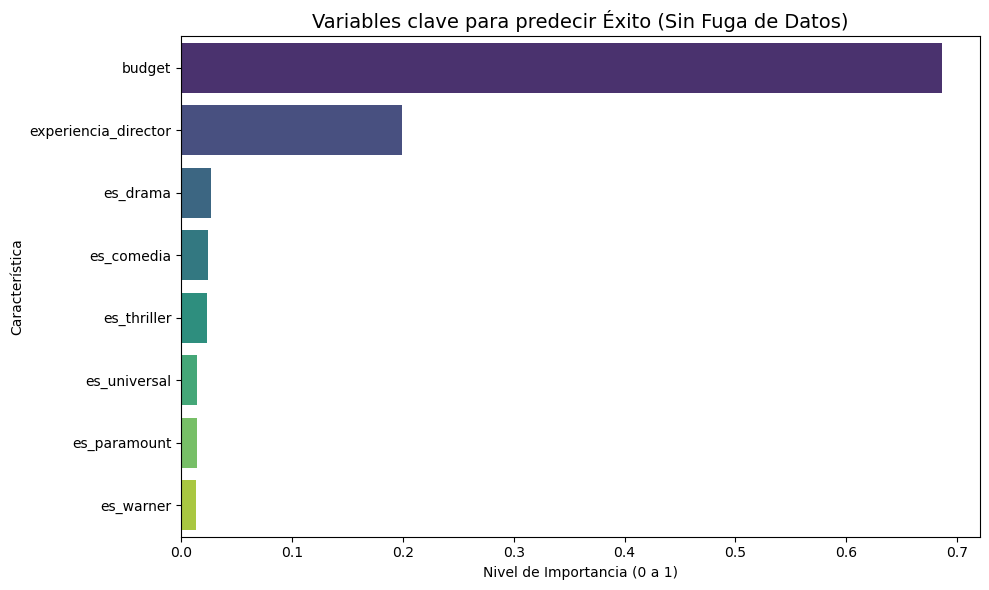

In [5]:
# Celda 5: Gráfico de Importancia Actualizado

importancias = modelo_pipeline_clf.named_steps['algoritmo'].feature_importances_

df_importancia_clf = pd.DataFrame({
    'Variable': features, # Usamos directamente la lista de features
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia_clf, palette='viridis')
plt.title('Variables clave para predecir Éxito (Sin Fuga de Datos)', fontsize=14)
plt.xlabel('Nivel de Importancia (0 a 1)')
plt.ylabel('Característica')
plt.tight_layout()
plt.savefig('../outputs/figures/importancia_clasificacion_v4.png')
plt.show()